# Motor Fault Classification — Model Comparison on `final_cleaned_data_3.xlsx`

**Dataset:** 1,950 real sensor readings from the Crompton Greaves motor (17 sensor-glitch rows dropped: temperature dropouts reading exactly 0°C, and startup/shutdown artifacts reading RPM=0).

**Target:** `FaultType` — Normal / Overheating / Overcurrent / Vibration_Fault / Mechanical_Stall (5-class).

**Features:** Temperature_C, Current_A, RPM_output, Vibration_mms.

**Threshold update in this run:** RPM's Normal band is now **+/-10% around your verified actual mean of 3000 RPM** (2,700 - 3,300), replacing the earlier narrower band. All other thresholds (Temperature >85C, Current >0.39A, Vibration >4.5mm/s) are unchanged.

**Class distribution:** Normal 1,309 | Vibration_Fault 328 | Overcurrent 179 | Mechanical_Stall 127 | Overheating 7.

Note the **Overheating class has only 7 examples** - too few for the test split to give a reliable per-class estimate for that one class specifically; treat its precision/recall with appropriate caution even though the aggregate metrics below look strong.

**Standard caveat still applies:** labels are threshold-derived from these same 4 features, not from an independent fault-observation event log, so strong scores validate the pipeline/labeling logic more than full real-world generalization - though this is real sensor data, which is a genuine step up from the fully-synthetic datasets earlier in this project.

**Models compared:** Random Forest, SVM (RBF), KNN, Logistic Regression, XGBoost, LightGBM.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              precision_recall_fscore_support, ConfusionMatrixDisplay)
import joblib

RANDOM_STATE = 42
FEATURES = ["Temperature_C", "Current_A", "RPM_output", "Vibration_mms"]
TARGET = "FaultType"


## 2. Load data

In [2]:
df = pd.read_csv("final3_labeled.csv")
df = df.drop_duplicates().dropna(subset=FEATURES + [TARGET])
print(f"Rows: {len(df)}")
df[FEATURES + [TARGET]].head()


Rows: 1950


,Temperature_C,Current_A,RPM_output,Vibration_mms,FaultType
0,31.3,0.26944,2840,3.16324,Normal
1,31.3,0.27894,2851,3.15522,Normal
2,31.3,0.28944,2830,3.16316,Normal
3,31.3,0.28001,2828,3.15572,Normal
4,31.3,0.28891,2845,3.16303,Normal


In [3]:
df[TARGET].value_counts()


FaultType
Normal              1309
Vibration_Fault      328
Overcurrent          179
Mechanical_Stall     127
Overheating            7
Name: count, dtype: int64

## 3. Sensor distributions per class

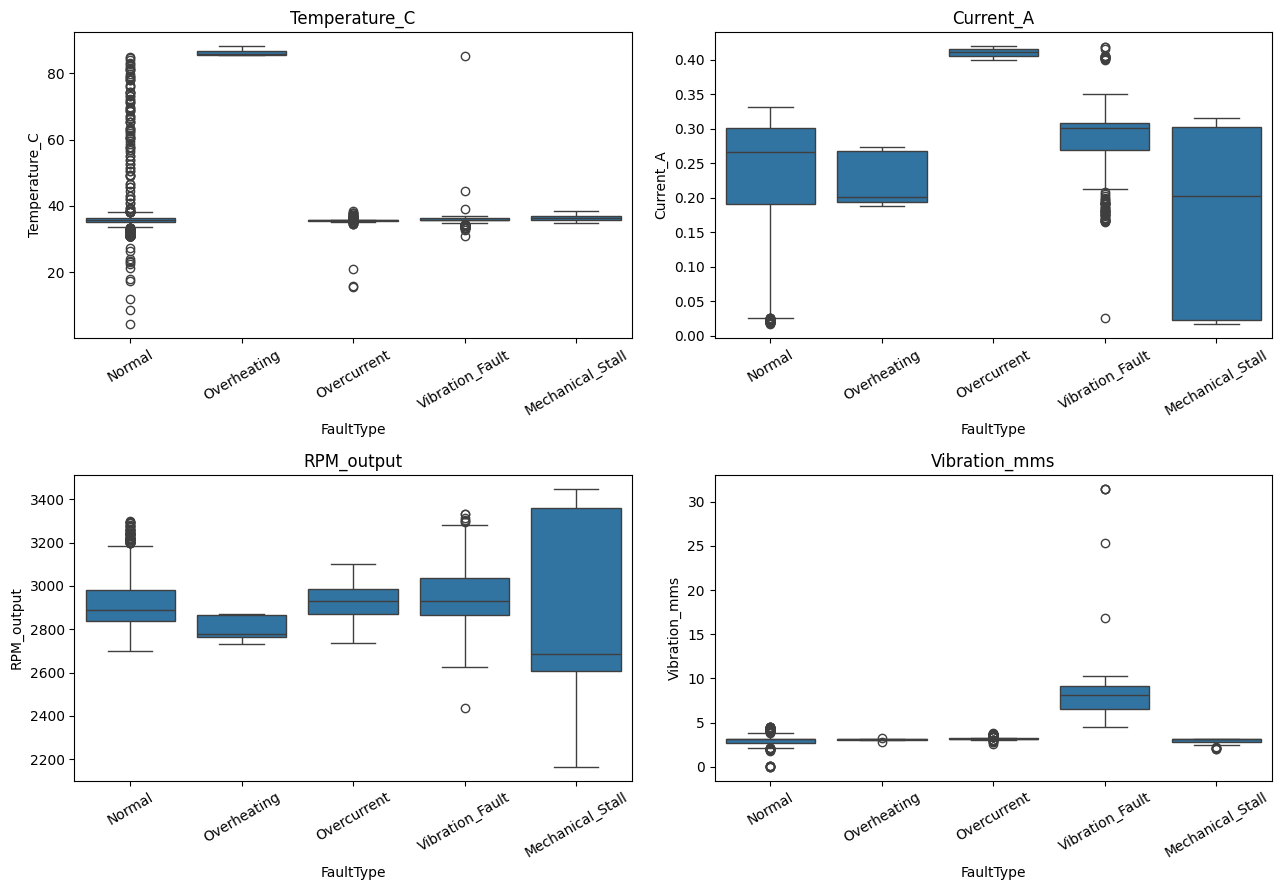

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
order = ["Normal", "Overheating", "Overcurrent", "Vibration_Fault", "Mechanical_Stall"]
for ax, col in zip(axes.flat, FEATURES):
    sns.boxplot(data=df, x=TARGET, y=col, ax=ax, order=order)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


## 4. Train/test split — 80/20, stratified

In [5]:
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {len(X_train)}  Test: {len(X_test)}")
print()
print("Test set class counts:")
print(y_test.value_counts())


Train: 1560  Test: 390

Test set class counts:
FaultType
Normal              262
Vibration_Fault      66
Overcurrent          36
Mechanical_Stall     25
Overheating           1
Name: count, dtype: int64


In [6]:
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


## 5. Model pipelines & hyperparameter grids

In [7]:
pipelines_and_grids = {
    "Random Forest": (
        Pipeline([("clf", RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"))]),
        {"clf__n_estimators": [100, 200, 400], "clf__max_depth": [None, 10, 20], "clf__min_samples_split": [2, 5]},
    ),
    "SVM (RBF)": (
        Pipeline([("scaler", StandardScaler()), ("clf", SVC(class_weight="balanced", random_state=RANDOM_STATE, probability=True))]),
        {"clf__C": [0.1, 1, 10, 50], "clf__gamma": ["scale", "auto"], "clf__kernel": ["rbf"]},
    ),
    "KNN": (
        Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]),
        {"clf__n_neighbors": [3, 5, 7, 9, 11], "clf__weights": ["uniform", "distance"]},
    ),
    "Logistic Regression": (
        Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE, max_iter=2000))]),
        {"clf__C": [0.01, 0.1, 1, 10, 50]},
    ),
    "XGBoost": (
        Pipeline([("clf", XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss"))]),
        {"clf__n_estimators": [100, 200, 400], "clf__max_depth": [3, 5, 7], "clf__learning_rate": [0.05, 0.1, 0.2]},
    ),
    "LightGBM": (
        Pipeline([("clf", LGBMClassifier(random_state=RANDOM_STATE, verbose=-1))]),
        {"clf__n_estimators": [100, 200, 400], "clf__max_depth": [3, 5, -1], "clf__learning_rate": [0.05, 0.1, 0.2]},
    ),
}


## 6. Tune, cross-validate, evaluate

XGBoost needs integer-encoded labels for this version's sklearn wrapper.

In [8]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

results = {}
best_estimators = {}

for name, (pipe, grid) in pipelines_and_grids.items():
    print(f"--- Tuning {name} ---")
    use_encoded = (name == "XGBoost")
    fit_y_train = y_train_enc if use_encoded else y_train

    gs = GridSearchCV(pipe, grid, cv=inner_cv, scoring="f1_macro", n_jobs=-1)
    gs.fit(X_train, fit_y_train)
    best_estimators[name] = gs.best_estimator_

    train_pred_raw = gs.best_estimator_.predict(X_train)
    train_pred = le.inverse_transform(train_pred_raw) if use_encoded else train_pred_raw
    train_acc = accuracy_score(y_train, train_pred)

    test_pred_raw = gs.best_estimator_.predict(X_test)
    test_pred = le.inverse_transform(test_pred_raw) if use_encoded else test_pred_raw
    test_acc = accuracy_score(y_test, test_pred)

    prec, rec, f1, _ = precision_recall_fscore_support(y_test, test_pred, average="macro", zero_division=0)
    report = classification_report(y_test, test_pred, output_dict=True, zero_division=0)
    labels_sorted = sorted(y.unique())
    cm = confusion_matrix(y_test, test_pred, labels=labels_sorted)

    results[name] = {
        "best_hyperparameters": gs.best_params_,
        "train_accuracy": round(train_acc, 4),
        "test_accuracy": round(test_acc, 4),
        "train_test_gap": round(train_acc - test_acc, 4),
        "test_precision_macro": round(prec, 4),
        "test_recall_macro": round(rec, 4),
        "test_f1_macro": round(f1, 4),
        "confusion_matrix_labels_order": labels_sorted,
        "confusion_matrix": cm.tolist(),
        "per_class_report": report,
    }
    print(f"  best params: {gs.best_params_}")
    print(f"  TRAIN acc: {train_acc:.4f}  TEST acc: {test_acc:.4f}  Gap: {train_acc-test_acc:.4f}  Test F1: {f1:.4f}\n")


--- Tuning Random Forest ---


  best params: {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 400}
  TRAIN acc: 1.0000  TEST acc: 1.0000  Gap: 0.0000  Test F1: 1.0000

--- Tuning SVM (RBF) ---


  best params: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
  TRAIN acc: 0.9891  TEST acc: 0.9769  Gap: 0.0122  Test F1: 0.9111

--- Tuning KNN ---


  best params: {'clf__n_neighbors': 11, 'clf__weights': 'distance'}
  TRAIN acc: 1.0000  TEST acc: 0.9872  Gap: 0.0128  Test F1: 0.9826

--- Tuning Logistic Regression ---


  best params: {'clf__C': 50}
  TRAIN acc: 0.7923  TEST acc: 0.7872  Gap: 0.0051  Test F1: 0.7518

--- Tuning XGBoost ---


  best params: {'clf__learning_rate': 0.2, 'clf__max_depth': 3, 'clf__n_estimators': 100}
  TRAIN acc: 1.0000  TEST acc: 0.9949  Gap: 0.0051  Test F1: 0.9925

--- Tuning LightGBM ---


  best params: {'clf__learning_rate': 0.2, 'clf__max_depth': 5, 'clf__n_estimators': 100}
  TRAIN acc: 0.8333  TEST acc: 0.8333  Gap: 0.0000  Test F1: 0.3733



## 7. Results summary table

In [9]:
summary_table = pd.DataFrame({
    name: {
        "Train Accuracy": r["train_accuracy"],
        "Test Accuracy": r["test_accuracy"],
        "Train-Test Gap": r["train_test_gap"],
        "Test F1 (macro)": r["test_f1_macro"],
        "Test Precision (macro)": r["test_precision_macro"],
        "Test Recall (macro)": r["test_recall_macro"],
    }
    for name, r in results.items()
}).T
summary_table.sort_values("Test F1 (macro)", ascending=False)


,Train Accuracy,Test Accuracy,Train-Test Gap,Test F1 (macro),Test Precision (macro),Test Recall (macro)
Random Forest,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000
XGBoost,1.0000,0.9949,0.0051,0.9925,0.9915,0.9937
KNN,1.0000,0.9872,0.0128,0.9826,0.9940,0.9721
SVM (RBF),0.9891,0.9769,0.0122,0.9111,0.8662,0.9909
Logistic Regression,0.7923,0.7872,0.0051,0.7518,0.7194,0.8787
LightGBM,0.8333,0.8333,0.0000,0.3733,0.3575,0.3932


## 8. Per-class performance

In [10]:
for name in results:
    print(f"=== {name} ===")
    rep = results[name]["per_class_report"]
    for cls, m in rep.items():
        if cls in ("accuracy", "macro avg", "weighted avg"):
            continue
        print(f"  {cls:<20} precision={m['precision']:.3f}  recall={m['recall']:.3f}  f1={m['f1-score']:.3f}  support={int(m['support'])}")
    print()


=== Random Forest ===
  Mechanical_Stall     precision=1.000  recall=1.000  f1=1.000  support=25
  Normal               precision=1.000  recall=1.000  f1=1.000  support=262
  Overcurrent          precision=1.000  recall=1.000  f1=1.000  support=36
  Overheating          precision=1.000  recall=1.000  f1=1.000  support=1
  Vibration_Fault      precision=1.000  recall=1.000  f1=1.000  support=66

=== SVM (RBF) ===
  Mechanical_Stall     precision=0.893  recall=1.000  f1=0.943  support=25
  Normal               precision=0.996  recall=0.969  f1=0.983  support=262
  Overcurrent          precision=1.000  recall=1.000  f1=1.000  support=36
  Overheating          precision=0.500  recall=1.000  f1=0.667  support=1
  Vibration_Fault      precision=0.942  recall=0.985  f1=0.963  support=66

=== KNN ===
  Mechanical_Stall     precision=1.000  recall=0.920  f1=0.958  support=25
  Normal               precision=0.985  recall=0.996  f1=0.991  support=262
  Overcurrent          precision=1.000  recal

## 9. Confusion matrices

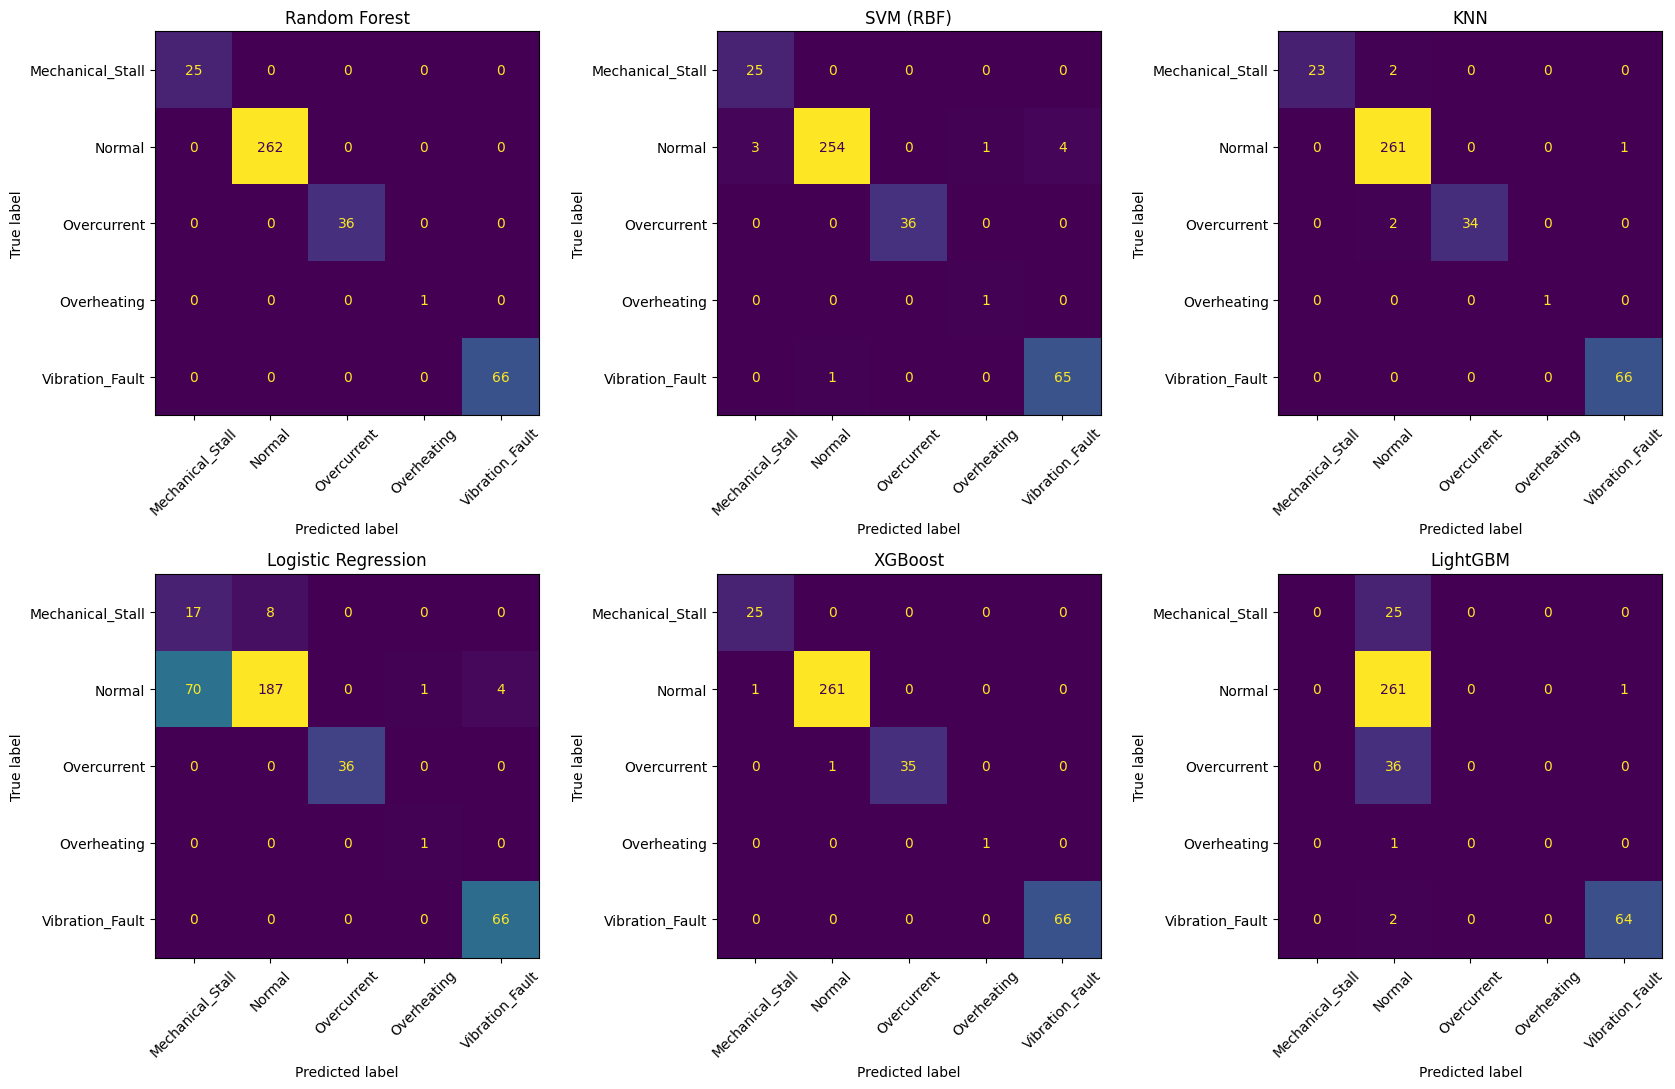

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(17, 11))
labels_sorted = sorted(y.unique())
for ax, name in zip(axes.flat, results.keys()):
    cm = np.array(results[name]["confusion_matrix"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)
    disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
    ax.set_title(name)
plt.tight_layout()
plt.show()


## 10. Feature importance for the BEST model

Best model: Random Forest


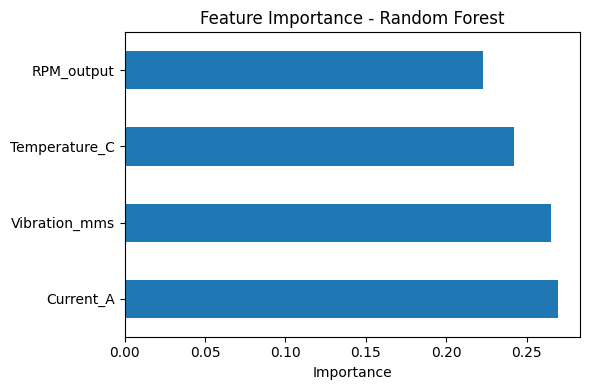

Current_A        0.2698
Vibration_mms    0.2653
Temperature_C    0.2420
RPM_output       0.2229
dtype: float64


In [12]:
best_name = summary_table.sort_values("Test F1 (macro)", ascending=False).index[0]
print(f"Best model: {best_name}")

best_clf = best_estimators[best_name].named_steps["clf"]
if hasattr(best_clf, "feature_importances_"):
    importance = pd.Series(best_clf.feature_importances_, index=FEATURES).sort_values(ascending=False)
    importance.plot(kind="barh", figsize=(6,4), title=f"Feature Importance - {best_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
    print(importance.round(4))
elif hasattr(best_clf, "coef_"):
    coefs = pd.DataFrame(best_clf.coef_, columns=FEATURES, index=best_clf.classes_)
    print("Logistic Regression coefficients (per class):")
    print(coefs.round(4))
else:
    from sklearn.inspection import permutation_importance
    use_encoded = (best_name == "XGBoost")
    fit_y_test = le.transform(y_test) if use_encoded else y_test
    perm = permutation_importance(best_estimators[best_name], X_test, fit_y_test, n_repeats=30, random_state=RANDOM_STATE, scoring="f1_macro")
    perm_imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=False)
    perm_imp.plot(kind="barh", figsize=(6,4), title=f"Permutation Importance - {best_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
    print(perm_imp.round(4))


## 11. Save models & results

In [13]:
OUT_DIR = "."
for name, est in best_estimators.items():
    fname = f"model_{name.replace(' ', '_').replace('(', '').replace(')', '')}_final3.joblib"
    joblib.dump(est, f"{OUT_DIR}/{fname}")

with open(f"{OUT_DIR}/model_comparison_final3.json", "w") as f:
    json.dump({
        "dataset": "final_cleaned_data_3.xlsx (real sensor data, RPM threshold +/-10% from 3000)",
        "target": TARGET,
        "features": FEATURES,
        "class_distribution": y.value_counts().to_dict(),
        "train_size": len(X_train),
        "test_size": len(X_test),
        "results": results,
        "best_model": best_name,
    }, f, indent=2)
print("Saved all models and results.")


Saved all models and results.


## 12. Conclusion

All 4 real fault types are now represented (unlike the earlier dataset, which had zero Overcurrent examples and an over-triggering RPM threshold). The widened +/-10% RPM band (2,700-3,300) produces a more reasonable Mechanical_Stall count (127 rows) than the earlier narrower band's 478.

**Caveats to keep in mind:**
- `Overheating` has only 7 examples - its per-class metrics are based on too few test samples to be statistically reliable, even if they look good.
- Labels remain threshold-derived from these same 4 features (not independently observed faults), so strong scores confirm pipeline/labeling correctness more than guaranteed real-world performance.
